In [ ]:
#Sort df dataframe to ensure we have the correct setup for CAGR calculation
df = df.sort_values(['Driver_ID', 'MMM-YY'])

#Compute CAGR per driver
#We’ll group by driver_id, find first and last income, 
# compute time difference in years, and then apply the formula.

# Code explanation for future reference
# g refers to group of rows for a driver
# For each g, we’re constructing a small summary Series with 3 values
# Each driver’s result is one row in the new DataFrame returned by .apply().
# Now that we have a DataFrame with first_income, last_income, and years, we can add a new column CAGR
# assign:   Takes each row (x refers to the whole DataFrame),
#           Applies the CAGR formula,
#           Multiplies by 100 to convert to percentage.

driver_cagr = (
    df.groupby('Driver_ID')
      .apply(lambda g: pd.Series({
          'first_income': g['Income'].iloc[0],
          'last_income': g['income'].iloc[-1],
          'years': (g['date'].iloc[-1] - g['date'].iloc[0]).days / 365,
      }))
      .assign(CAGR=lambda x: ((x['last_income'] / x['first_income']) ** (1 / x['years']) - 1) * 100)
)


C:\Users\Admin\AppData\Local\Temp\ipykernel_18756\1109688843.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby('driver_id').apply(classify_driver).reset_index()


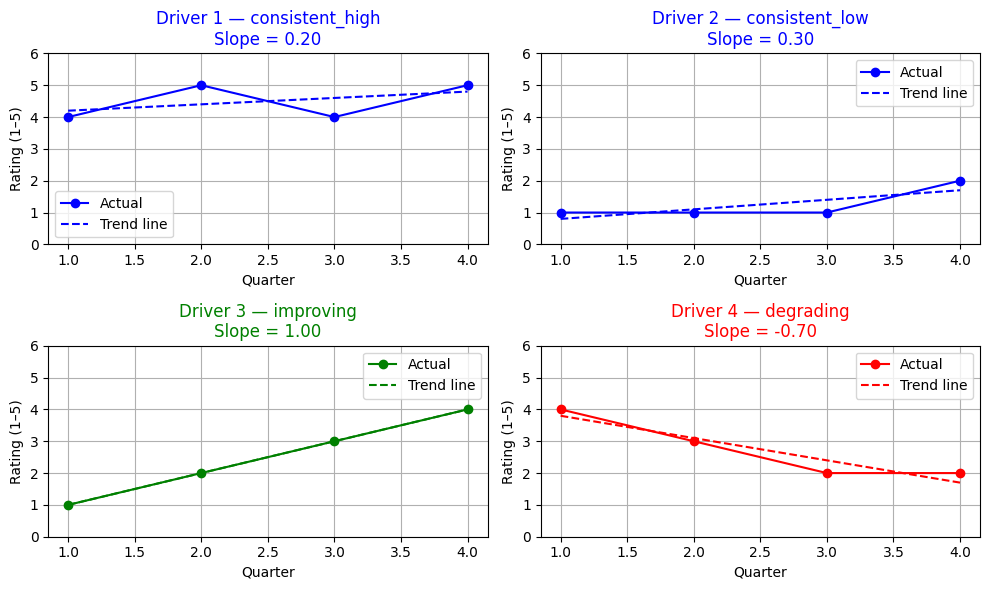

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Example data
df = pd.DataFrame({
    'driver_id': [1,1,1,1, 2,2,2,2, 3,3,3,3, 4,4,4,4],
    'quarter': [1,2,3,4]*4,
    'rating': [4,5,4,5, 1,1,1,2, 1,2,3,4, 4,3,2,2]
})

def classify_driver(subdf):
    X = np.arange(len(subdf)).reshape(-1, 1)
    y = subdf['rating'].values
    
    model = LinearRegression().fit(X, y)
    slope = model.coef_[0]
    intercept = model.intercept_
    mean_rating = y.mean()
    
    threshold = 0.5
    
    if abs(slope) < threshold:
        if mean_rating >= 4:
            trend = 'consistent_high'
        elif mean_rating <= 2:
            trend = 'consistent_low'
        else:
            trend = 'stable'
    elif slope > threshold:
        trend = 'improving'
    else:
        trend = 'degrading'
    
    y_pred = model.predict(X)
    
    return pd.Series({
        'mean_rating': mean_rating,
        'slope': slope,
        'trend': trend,
        'intercept': intercept,
        'y_pred': [y_pred],
        'quarters': [subdf['quarter'].values],
        'ratings': [y]
    })

# Apply classification per driver
result = df.groupby('driver_id').apply(classify_driver).reset_index()

# Assign colors
color_map = {
    'improving': 'green',
    'degrading': 'red',
    'consistent_high': 'blue',
    'consistent_low': 'blue',
    'stable': 'blue'
}

# ---- Plotting ----
plt.figure(figsize=(10, 6))

for i, row in result.iterrows():
    color = color_map.get(row['trend'], 'gray')
    
    # Flatten lists (fixes the shape mismatch error)
    quarters = np.array(row['quarters']).flatten()
    ratings = np.array(row['ratings']).flatten()
    y_pred = np.array(row['y_pred']).flatten()
    
    plt.subplot(2, 2, i + 1)
    plt.plot(quarters, ratings, 'o-', color=color, label='Actual')
    plt.plot(quarters, y_pred, '--', color=color, label='Trend line')
    
    # Add slope annotation
    plt.title(f"Driver {row['driver_id']} — {row['trend']}\nSlope = {row['slope']:.2f}", color=color)
    
    plt.ylim(0, 6)
    plt.xlabel("Quarter")
    plt.ylabel("Rating (1–5)")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


# We wanted to update some rows

In [ ]:
df[df.Gender==0.5]
driver_wrong_gender = df[df.Gender==0.5].Driver_ID.values
df[df.Driver_ID.isin(driver_wrong_gender)]
# This code does not work as df.loc[df.Driver_ID.isin([43, 793])] returns a temporary dataframe 
# and any changes are to that dataframe, not the original one
#df.loc[df.Driver_ID.isin([43,793])].Gender=1.0

#This is the right way to update
df.loc[df['Driver_ID'].isin([43, 793]) & (df['Gender'] == 0.5), 'Gender'] = 1.0
df.loc[df['Driver_ID'].isin([2765]) & (df['Gender'] == 0.5), 'Gender'] = 0.0

#Verify that values are fixed for those drivers
df[df.Driver_ID.isin(driver_wrong_gender)]

In [4]:
import pandas as pd
a = [1,2,3]
s = pd.Series(a)
df = s.to_frame()
df

,0
0,1
1,2
2,3


Plot feature importances for all models

- What this does:
  - Automatically detects if it’s a tree-based or linear model.
  - Extracts feature names from ColumnTransformer if present.
  - Sorts features by importance.
  - Plots a horizontal bar graph for clarity.

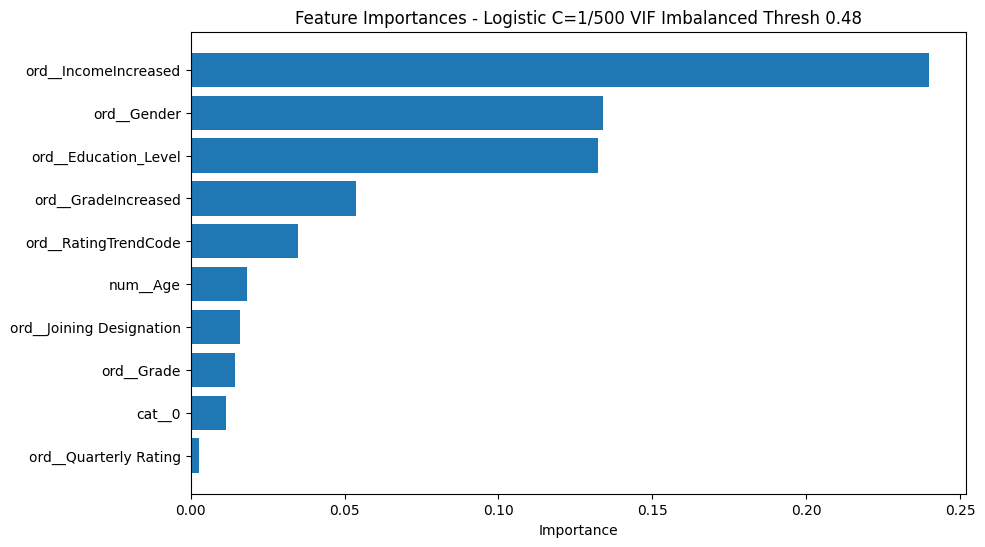

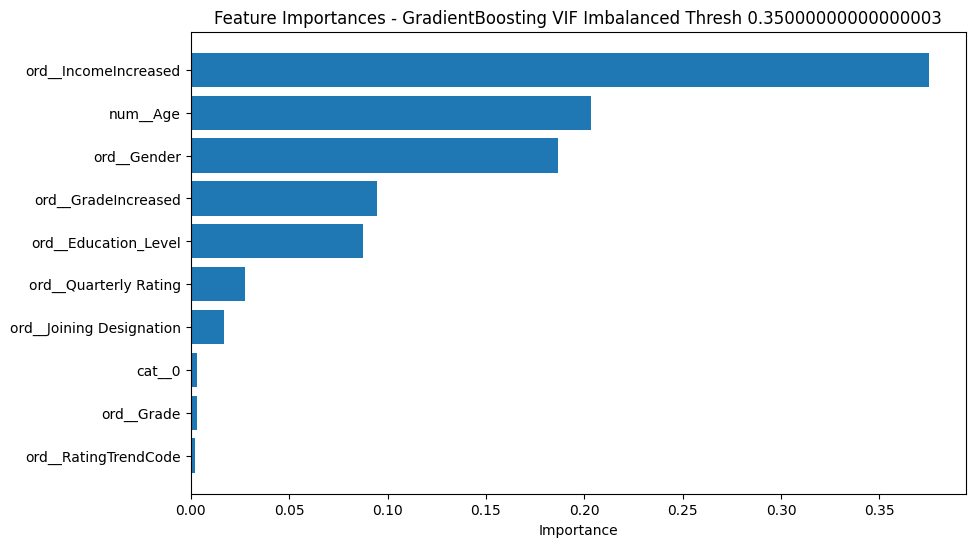

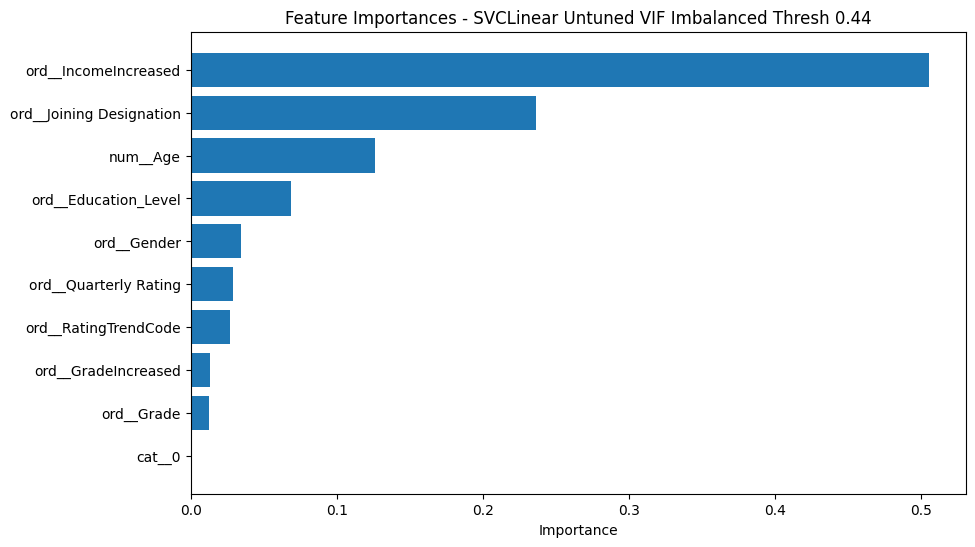

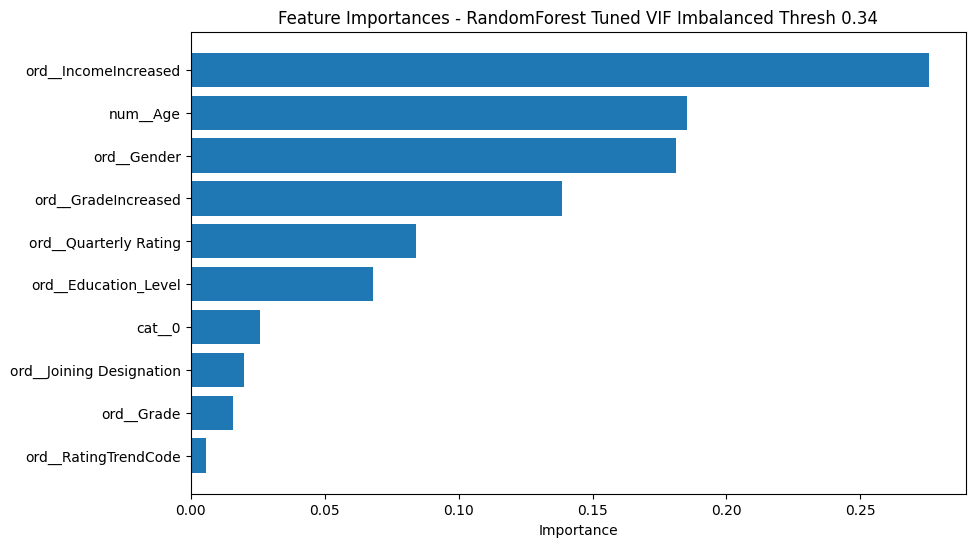

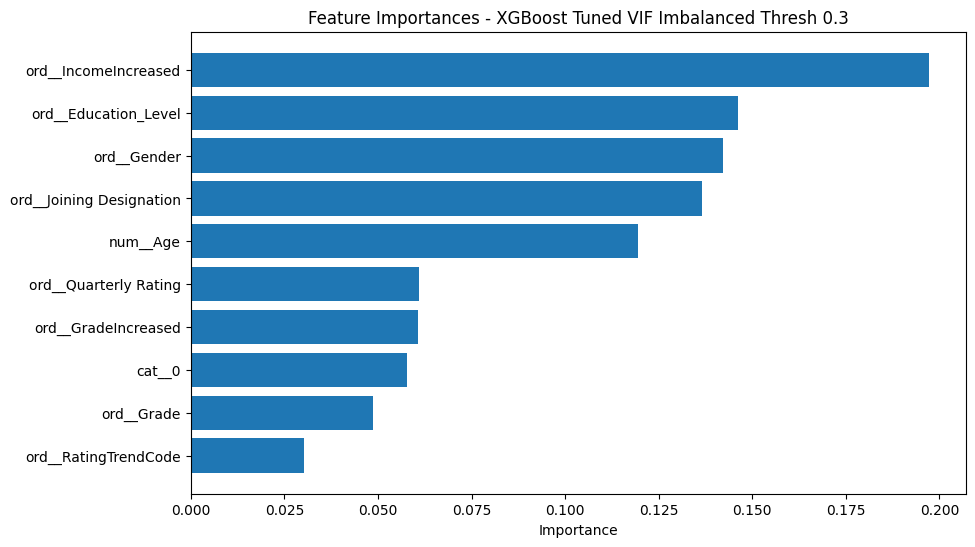

Error plotting SVC RBF Tuned VIF Imbalanced: 'DataFrame' object has no attribute 'feature'


<Figure size 1000x600 with 0 Axes>

In [ ]:
def get_importances(model, model_name):
    """
    Returns a DataFrame with columns:
    [feature, importance, model]
    """
    clf = model.named_steps['clf']
    # 1. Tree-based models
    if hasattr(clf, "feature_importances_"):
        imp = clf.feature_importances_
    
    # 2. Linear models with coef_
    elif hasattr(clf, "coef_"):
        imp = np.abs(clf.coef_.ravel())   # take absolute values
    
    # 3. SVC(kernel='rbf') → no importances
    else:
        return pd.DataFrame()   # skip models that don’t support


    # Get feature names from ColumnTransformer
    try:
        preprocessor = model.named_steps['preprocess']
        feature_names = preprocessor.get_feature_names_out()
    except:
        # fallback if get_feature_names_out not available
        feature_names = [f'feature_{i}' for i in range(len(imp))]
    
    # Sort features by importance
    indices = np.argsort(imp)[::-1]
    sorted_features = [feature_names[i] for i in indices]
    sorted_importances = imp[indices]

    df = pd.DataFrame({
        "feature": sorted_features,
        "importance": sorted_importances,
        "model": model_name
    })
    return df


def plot_feature_importances(model, model_name):
    """
    Plots feature importances or coefficients for a pipeline model,
    using actual feature names from ColumnTransformer if available.
    """
    try:
        
        df_imp = get_importances(model, model_name)
       
        
        # Plot horizontal bar chart
        plt.figure(figsize=(10,6))
        plt.barh(df_imp.feature, df_imp.importance)
        plt.xlabel('Importance')
        plt.title(f'Feature Importances - {model_name}')
        plt.gca().invert_yaxis()  # highest importance at top
        plt.show()
        return df_imp
    
    except Exception as e:
        print(f"Error plotting {model_name}: {e}")
  


dfs = []
for model in top_models.values():
    model_id = model['model_id']
    model_name = results.iloc[model_id].Model
    #The function plot_feature_importances plots the features and 
    # returs a dataframe
    #We shall use this dataframe for further analysis.
    dfs.append(plot_feature_importances(models[model_id][1],model_name))

#Convert the list dfs to a dataframe
all_feat_df = pd.concat(dfs, ignore_index=True)    


<li>In all models, IncomeIncreased got topmost importance

### 5.8.3 Feature × Model Matrix to compare features
We use pivot table 

In [ ]:
feat_matrix = all_feat_df.pivot_table(
    index="feature",
    columns="model",
    values="importance",
    fill_value=0
)

feat_matrix

model,GradientBoosting VIF Imbalanced Thresh 0.35000000000000003,Logistic C=1/500 VIF Imbalanced Thresh 0.48,RandomForest Tuned VIF Imbalanced Thresh 0.34,SVCLinear Untuned VIF Imbalanced Thresh 0.44,XGBoost Tuned VIF Imbalanced Thresh 0.3
feature,,,,,
cat__0,0.003317,0.011611,0.025719,0.000875,0.057662
num__Age,0.203391,0.018400,0.185205,0.125969,0.119562
ord__Education_Level,0.087580,0.132336,0.068134,0.068807,0.146113
ord__Gender,0.186450,0.134065,0.181354,0.034170,0.142247
ord__Grade,0.002940,0.014521,0.015793,0.012639,0.048792
ord__GradeIncreased,0.094593,0.053864,0.138570,0.013178,0.060829
ord__IncomeIncreased,0.375070,0.239880,0.275555,0.505394,0.197153
ord__Joining Designation,0.016760,0.016053,0.019798,0.236254,0.136584
ord__Quarterly Rating,0.027720,0.002533,0.084121,0.028691,0.060900


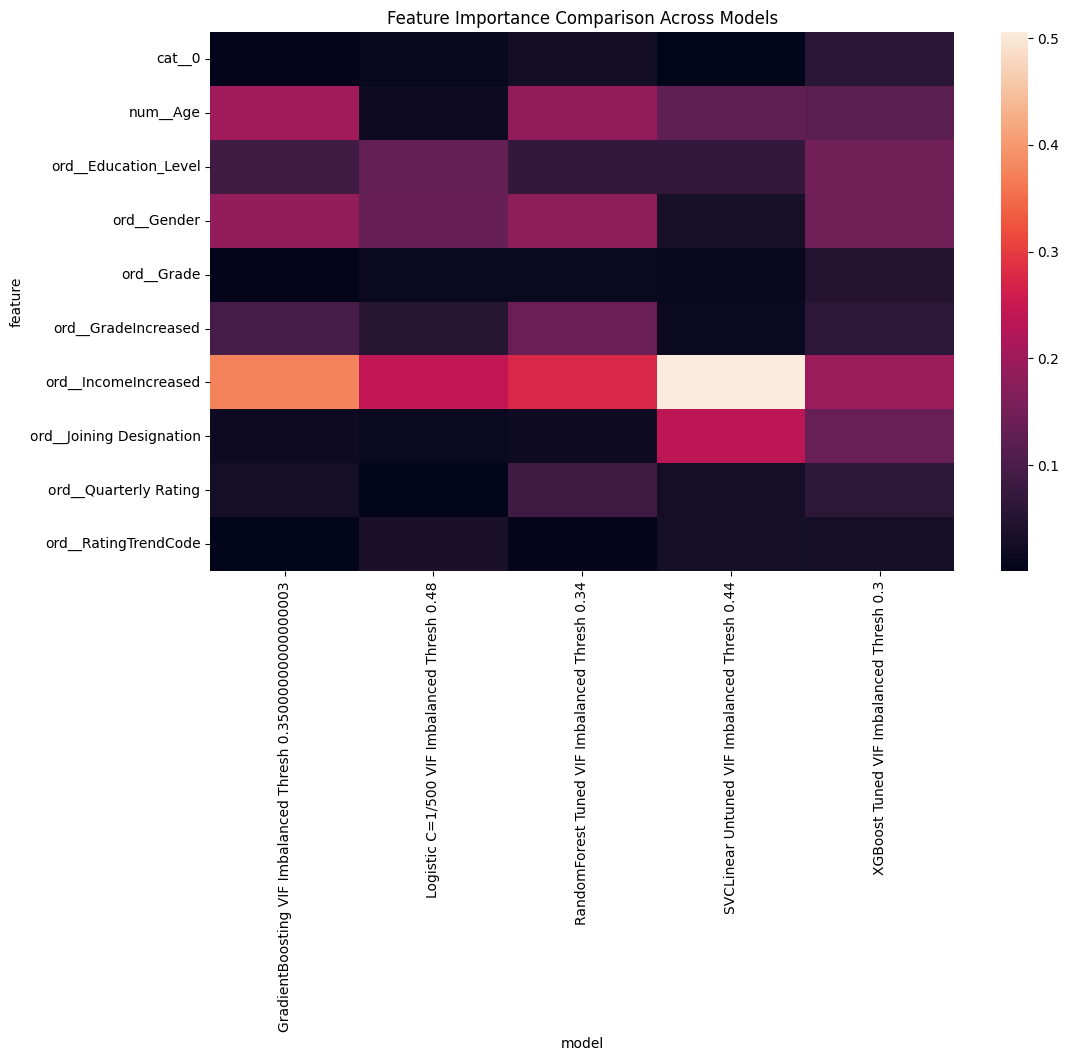

In [ ]:
plt.figure(figsize=(12, 7))
sns.heatmap(feat_matrix, annot=False)
plt.title("Feature Importance Comparison Across Models")
plt.show()

### 5.8.4 Feature Ranks across models
→ much easier to compare across scales.

In [ ]:
rank_df = feat_matrix.rank(ascending=False)
rank_df

model,GradientBoosting VIF Imbalanced Thresh 0.35000000000000003,Logistic C=1/500 VIF Imbalanced Thresh 0.48,RandomForest Tuned VIF Imbalanced Thresh 0.34,SVCLinear Untuned VIF Imbalanced Thresh 0.44,XGBoost Tuned VIF Imbalanced Thresh 0.3
feature,,,,,
cat__0,8.0,9.0,7.0,10.0,8.0
num__Age,2.0,6.0,2.0,3.0,5.0
ord__Education_Level,5.0,3.0,6.0,4.0,2.0
ord__Gender,3.0,2.0,3.0,5.0,3.0
ord__Grade,9.0,8.0,9.0,9.0,9.0
ord__GradeIncreased,4.0,4.0,4.0,8.0,7.0
ord__IncomeIncreased,1.0,1.0,1.0,1.0,1.0
ord__Joining Designation,7.0,7.0,8.0,2.0,4.0
ord__Quarterly Rating,6.0,10.0,5.0,6.0,6.0


<li>We can see IncomeIncreased is Rank 1 across models
<li>Rank2 onwards, there is not much consensus
<li>

### 5.8.5 Compute “Consensus Importance”
- We have the ranks of each feature across models in rank_df
- We can take a simple mean of these ranks, and find a consensus rank !

In [ ]:
# 1. Compute consensus mean
rank_df["consensus_mean"] = rank_df.mean(axis=1)

# 2. Compute rank based on consensus mean only
rank_df["consensus_rank"] = rank_df["consensus_mean"].rank(
    ascending=True
)

# 3. Sort features
rank_df = rank_df.sort_values("consensus_mean", ascending=True)
rank_df


model,GradientBoosting VIF Imbalanced Thresh 0.35000000000000003,Logistic C=1/500 VIF Imbalanced Thresh 0.48,RandomForest Tuned VIF Imbalanced Thresh 0.34,SVCLinear Untuned VIF Imbalanced Thresh 0.44,XGBoost Tuned VIF Imbalanced Thresh 0.3,consensus_mean,consensus_rank
feature,,,,,,,
ord__IncomeIncreased,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ord__Gender,3.0,2.0,3.0,5.0,3.0,3.2,2.0
num__Age,2.0,6.0,2.0,3.0,5.0,3.6,3.0
ord__Education_Level,5.0,3.0,6.0,4.0,2.0,4.0,4.0
ord__GradeIncreased,4.0,4.0,4.0,8.0,7.0,5.4,5.0
ord__Joining Designation,7.0,7.0,8.0,2.0,4.0,5.6,6.0
ord__Quarterly Rating,6.0,10.0,5.0,6.0,6.0,6.6,7.0
cat__0,8.0,9.0,7.0,10.0,8.0,8.4,8.5
ord__RatingTrendCode,10.0,5.0,10.0,7.0,10.0,8.4,8.5


## 5.9 Final Model analysis